Loading dataset... this might take a moment depending on RAM.
Dataset Loaded Successfully! Shape: (211043, 44)
------------------------------
Shape after cleaning NaNs/Infinity: (211043, 44)
------------------------------

--- Distribution of Attack Types ---
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
ransomware    20000
scanning      20000
xss           20000
mitm           1043
Name: count, dtype: int64


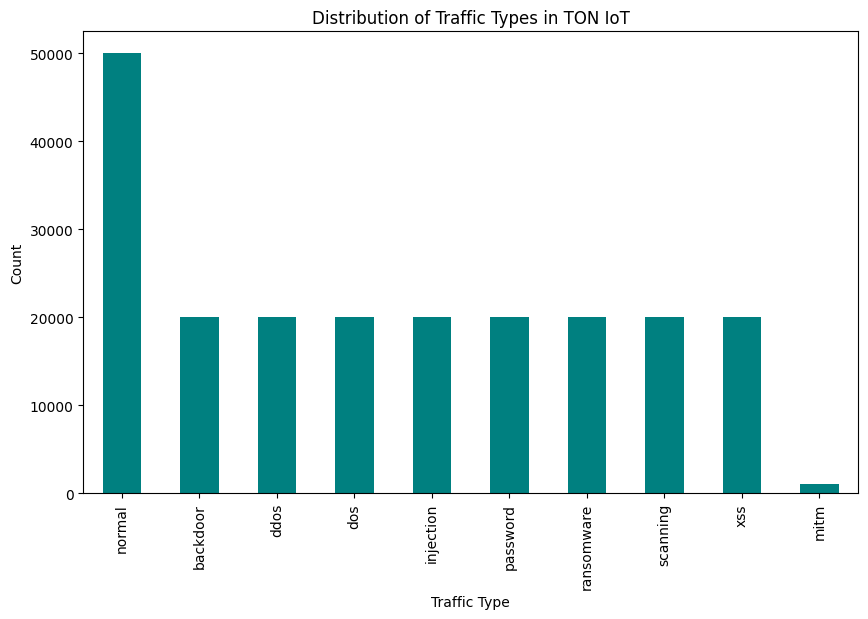


--- First 5 Rows of Data ---


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_query,dns_qclass,dns_qtype,dns_rcode,dns_AA,dns_RD,dns_RA,dns_rejected,ssl_version,ssl_cipher,ssl_resumed,ssl_established,ssl_subject,ssl_issuer,http_trans_depth,http_method,http_uri,http_version,http_request_body_len,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,0,108,108064,31,3832,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,0,1,48,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# Adjust this path if your file is named differently or located elsewhere
FILE_PATH = '/Users/varattsaengsiripongpun/Documents/Reinforcement/HydraAIops/data/raw/train_test_network.csv' 

print("Loading dataset... this might take a moment depending on RAM.")

# 1. Load the Data
# low_memory=False is often needed for network datasets because mixed types can occur in columns
df = pd.read_csv(FILE_PATH, low_memory=False)

print(f"Dataset Loaded Successfully! Shape: {df.shape}")
print("-" * 30)

# 2. Basic Cleaning
# Network flows often contain 'Infinity' or NaN values which break ML models. 
# We replace them with 0 or drop them.
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f"Shape after cleaning NaNs/Infinity: {df.shape}")
print("-" * 30)

# 3. Inspect the 'Targets' (What we want to predict)
# In TON_IoT, 'type' is usually the specific attack (e.g., 'ddos', 'backdoor')
# 'label' is usually binary (0 = Normal, 1 = Attack)

if 'type' in df.columns:
    print("\n--- Distribution of Attack Types ---")
    print(df['type'].value_counts())
    
    # Simple Bar Plot
    plt.figure(figsize=(10,6))
    df['type'].value_counts().plot(kind='bar', color='teal')
    plt.title('Distribution of Traffic Types in TON IoT')
    plt.xlabel('Traffic Type')
    plt.ylabel('Count')
    plt.show()

# 4. Peek at the features
print("\n--- First 5 Rows of Data ---")
pd.set_option('display.max_columns', None) # Force VS Code to show all columns
display(df.head())

Preprocessing data...
Training data shape: (147730, 40)
Testing data shape: (63313, 40)
------------------------------
Training Random Forest (this may take 1-2 minutes)...
Training Complete!
Evaluating model...

--- Classification Report ---
              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      5898
        ddos       0.99      0.98      0.98      6019
         dos       0.99      0.98      0.99      5906
   injection       0.98      0.97      0.97      6025
        mitm       0.71      0.83      0.76       322
      normal       1.00      1.00      1.00     15045
    password       0.99      0.99      0.99      5972
  ransomware       1.00      1.00      1.00      6007
    scanning       0.99      0.99      0.99      6093
         xss       0.98      0.98      0.98      6026

    accuracy                           0.99     63313
   macro avg       0.96      0.97      0.97     63313
weighted avg       0.99      0.99      0.99     63313

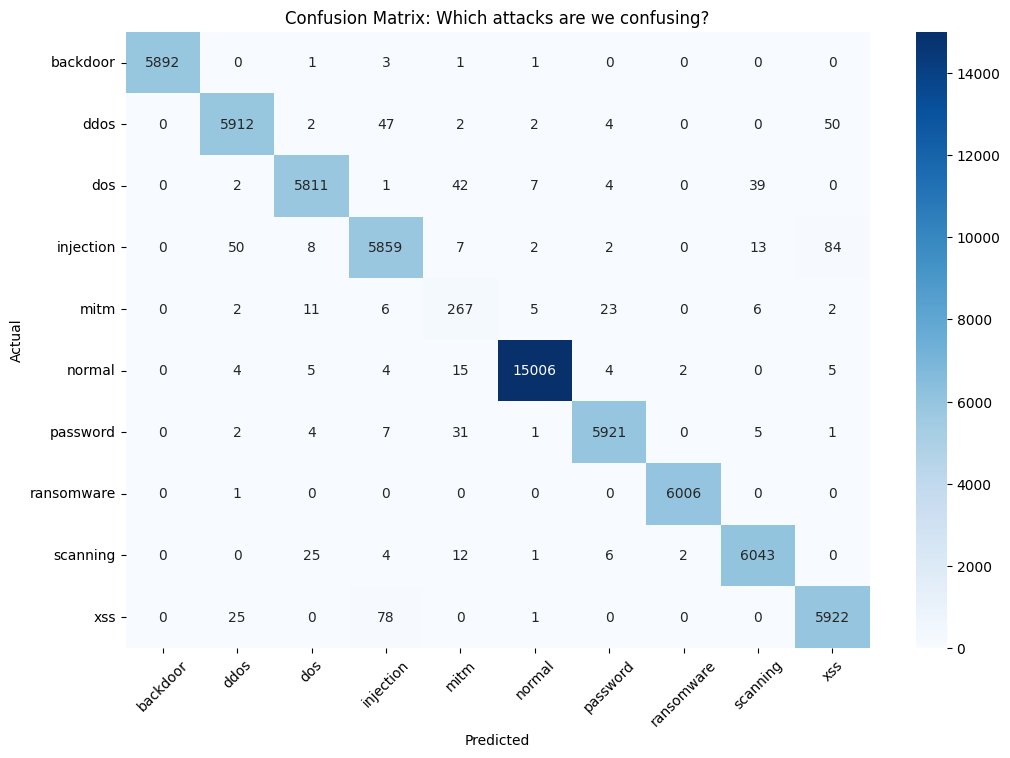

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# --- 1. PREPROCESSING ---
print("Preprocessing data...")

# Create a copy so we don't mess up the original dataframe
df_clean = df.copy()

# DROP columns that cause overfitting or "leak" answers
# We drop IPs because we want to detect the *behavior*, not the specific computer.
# We drop 'ts' (timestamp) because time of day shouldn't determine maliciousness yet.
# Adjust these column names if your dataset uses slightly different capitalization
cols_to_drop = ['src_ip', 'dst_ip', 'ts', 'date', 'time'] 
# Only drop if they actually exist in your dataframe
existing_drop_cols = [c for c in cols_to_drop if c in df_clean.columns]
df_clean.drop(columns=existing_drop_cols, inplace=True)

# ENCODE Categorical Columns (Turn strings like 'tcp', 'http' into numbers)
# We find all columns that are still "object" (text) type
categorical_cols = df_clean.select_dtypes(include=['object']).columns

# We use LabelEncoder to turn text into IDs (0, 1, 2...)
# Note: In a real production system, you'd save these encoders to reuse them later!
le_dict = {}
for col in categorical_cols:
    if col != 'type' and col != 'label': # Don't encode the target yet if you want to read it
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        le_dict[col] = le

# --- 2. DEFINE TARGETS ---
# X = The data (Features)
# y = The answer (Target)
X = df_clean.drop(columns=['type', 'label']) # distinct 'type' is our target for multi-class
y = df_clean['type']

# Split: 70% for Training, 30% for Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print("-" * 30)

# --- 3. TRAIN MODEL ---
print("Training Random Forest (this may take 1-2 minutes)...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all CPU cores
rf_model.fit(X_train, y_train)
print("Training Complete!")

# --- 4. EVALUATE ---
print("Evaluating model...")
y_pred = rf_model.predict(X_test)

# Print the Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix (To see where it gets confused)
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Confusion Matrix: Which attacks are we confusing?')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45)
plt.show()


In [4]:
import joblib
import os

# Create the directory if it doesn't exist
os.makedirs('../src/models', exist_ok=True)

# Save the model and the label encoders
joblib.dump(rf_model, '../src/models/statistical_head_rf.pkl')
joblib.dump(le_dict, '../src/models/label_encoders.pkl')

print("Model saved to src/models/statistical_head_rf.pkl")

Model saved to src/models/statistical_head_rf.pkl
